# Attribute Projections for Conflict Similarity in Text Embeddings

**Concept207 · MiniLM 384D · 240 English triplets**

This experiment examines whether a fixed attribute projection helps identify a shared decision conflict across different subject matters. The 207 decision attributes originate from [Bhatia et al. (PNAS, 2025)](https://doi.org/10.1073/pnas.2406489122).

Bhatia and colleagues analysed more than 100,000 dilemmas from Reddit and a US survey. Their pipeline extracted benefits and costs with GPT and represented them using SBERT and 207 attributes. In Study 4a, fitted individual attribute models achieved a mean $R^2$ of 0.24, compared with 0.14 for text and random-attribute models. Those fits used eight dilemmas per participant; this was not a dilemma-retrieval benchmark. The present experiment borrows the attribute system and applies it to whole texts.

**Main findings on this fixed corpus:** Concept207 achieves the highest triplet accuracy. In the exploratory corpus retrieval task, Hybrid50 outperforms both Embedding and Concept207 separately at nDCG@5 and nDCG@10. These are distinct evaluations; the retrieval extension was not prespecified.

## Objective and hypotheses

Each triplet contains an anchor A, a candidate B with the same authored conflict class in a different topic, and a candidate C with a different conflict in the same assigned topic. The target ordering is $d(A,B)<d(A,C)$.

**Primary hypothesis H1:** Concept207 increases the proportion of target orderings relative to the original embedding.

**Secondary hypothesis H2:** Hybrid50, a fixed 50/50 mixture of the embedding and Concept207 distances, also increases this proportion relative to the embedding.

The central object is Concept207. The hybrid tests an additional use of that representation. The projection changes the geometry of the original embedding; it does not create new information.

## Reproduction settings

Select `cached` for an offline recomputation from the supplied vectors, or `full` to encode all texts and attribute descriptions again with the pinned MiniLM model. Both modes recompute scores, random controls and bootstrap intervals. The first full run downloads model weights and takes longer. Python 3.12 is the reference environment. In Colab the setup cell installs dependencies and obtains the repository; locally install the relevant requirements first.


In [1]:
MODE = "cached"  #@param ["cached", "full"]

from pathlib import Path
import importlib.util
import subprocess
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "reproduce.py").is_file()), None)
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False
if ROOT is None:
    if not IN_COLAB:
        raise RuntimeError("Open this notebook inside a clone of concept-projection-dilemmas.")
    ROOT = Path.cwd() / "concept-projection-dilemmas"
    if not ROOT.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/sarrumkin/concept-projection-dilemmas.git", str(ROOT)], check=True)
    if not (ROOT / "reproduce.py").is_file():
        raise RuntimeError("The destination does not contain the research repository.")
if IN_COLAB:
    if MODE == "full":
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "torch==2.12.0", "--index-url", "https://download.pytorch.org/whl/cpu"], check=True)
    requirements = "requirements-full.txt" if MODE == "full" else "requirements.txt"
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-r", str(ROOT / requirements)], check=True)
print(f"Mode: {MODE}. Outputs are written to a separate artifacts directory.")

Mode: cached. Outputs are written to a separate artifacts directory.


In [2]:
import json
import uuid
import pandas as pd
from IPython.display import Markdown, display, Image

RELATIVE_RUN = Path("artifacts") / ("notebook_" + MODE + "_" + uuid.uuid4().hex[:8])
subprocess.run([sys.executable, "reproduce.py", "--mode", MODE, "--output", str(RELATIVE_RUN)], cwd=ROOT, check=True)
RUN = ROOT / RELATIVE_RUN
scores = pd.read_csv(RUN / "per_triplet.csv")
summary = pd.read_csv(RUN / "summary.csv")
intervals = pd.read_csv(RUN / "intervals.csv")
triplets = {row["id"]: row for row in json.loads((ROOT / "study/original/data/triplets.json").read_text())}
display(Markdown("**Recomputation complete.** The following tables use this run's outputs."))

Recomputing from saved embeddings and fixed anchors.
    method  n_triplets  correct_score  accuracy  mean_margin
concept207         240          145.0  0.604167     0.056505
 embedding         240          111.0  0.462500    -0.011749
  hybrid50         240          133.0  0.554167     0.022378
    method   baseline           grouping   metric  difference       low      high
  hybrid50  embedding conflict_and_topic accuracy    0.091667  0.004167  0.195833
  hybrid50  embedding           conflict accuracy    0.091667  0.037500  0.141667
  hybrid50  embedding       anchor_topic accuracy    0.091667  0.033333  0.154167
concept207  embedding conflict_and_topic accuracy    0.141667  0.025000  0.270833
concept207  embedding           conflict accuracy    0.141667  0.079167  0.208333
concept207  embedding       anchor_topic accuracy    0.141667  0.054167  0.229167
  hybrid50 concept207 conflict_and_topic accuracy   -0.050000 -0.125000  0.025000
  hybrid50 concept207           conflict accura

**Recomputation complete.** The following tables use this run's outputs.

## Verified illustrations of changed rankings

The two examples below were selected after scoring to illustrate a change from C to B. Both final AI audits prefer B. They are examples of the observed behaviour, not independent evidence for the aggregate hypothesis. Texts are reproduced in full; distances are calculated by the current run. Smaller distance is preferred.


In [3]:
METHODS = ["embedding", "concept207", "hybrid50"]
NAMES = {"embedding": "Embedding", "concept207": "Concept207", "hybrid50": "Hybrid50"}
for identifier in ["e266383", "e365088"]:
    row = triplets[identifier]
    display(Markdown(f"### {identifier} — {row['conflict'].replace('_', ' ')}"))
    for role in ["A", "B", "C"]:
        display(Markdown(f"**{role}.** {row[role]}"))
    selected = scores[scores.id == identifier].set_index("method").loc[METHODS]
    table = selected[["d_same_conflict", "d_same_topic"]].rename(columns={"d_same_conflict": "d(A, B)", "d_same_topic": "d(A, C)"})
    table.insert(0, "Method", [NAMES[m] for m in table.index])
    table["Preferred"] = ["B" if a < b else "C" if a > b else "Tie" for a, b in zip(table["d(A, B)"], table["d(A, C)"])]
    display(table.style.hide(axis="index").format({"d(A, B)": "{:.5f}", "d(A, C)": "{:.5f}"}))

### e266383 — health vs duty

**A.** Helen committed to play the solo at a benefit concert whose ticket revenue will keep a youth orchestra operating. On performance day, tendon pain returns in her wrist, and her doctor warns that playing may prolong the injury. Canceling could trigger refunds the orchestra cannot absorb. Should Helen perform as promised or protect her recovery?

**B.** A snowplow driver nearing the end of a double shift feels dizzy and nauseated. The only replacement is still two hours away, while an ambulance route to the county hospital is rapidly disappearing under snow. Stopping would protect his health but leave emergency crews without the cleared road he was assigned. Should he continue or pull over?

**C.** A theater director can replace the company’s hand-painted scenery with digital projections that allow faster scene changes and new visual effects. Older members treasure the backdrops painted by generations of local artists and view their yearly repair ritual as part of the theater’s identity. Should the director adopt projections or preserve the traditional sets?

Method,"d(A, B)","d(A, C)",Preferred
Embedding,0.87150,0.65960,C
Concept207,0.61701,1.01890,B
Hybrid50,0.74425,0.83925,B


### e365088 — ambition vs belonging

**A.** Tessa can lease a large vineyard in another region and finally produce wine under her own name. The move would separate her from the cooperative where neighbors share machinery, celebrate harvests, and have worked beside her since childhood. If she stays, her operation will remain modest; should she pursue the vineyard or keep her place in the cooperative?

**B.** When a national retailer offers to stock Amir’s ceramics, he must open a second workshop in another city and oversee it personally for eighteen months. The deal could transform his shop, but he would lose the daily contact he values with his partner and longtime market community. Should Amir accept the expansion or preserve his life among them?

**C.** Rosa can plant an unfamiliar drought-resistant melon that might thrive in the changing climate and earn a premium, though no local grower knows how it will perform. Her usual barley has a guaranteed buyer and predictable yield but little upside. Should she experiment with the melon or choose the protected return of barley?

Method,"d(A, B)","d(A, C)",Preferred
Embedding,0.57383,0.43634,C
Concept207,0.48518,0.64617,B
Hybrid50,0.52950,0.54125,B


## Design and method

The corpus contains **720 unique English texts in 240 triplets**: 12 conflict classes × 10 assigned topics × 2 variants. Four AI authors produced the texts. Labels, topic names and audit explanations are excluded from encoder input. The encoder is `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` at revision `e8f8c211226b894fcb81acc59f3b34ba3efd5f42`, with 384 output dimensions and a 128-token limit. All dilemma texts fit that limit.

Let $z$ be a unit text embedding and $P$ the fixed $207\times384$ matrix of attribute prototypes. Each prototype combines the unit means of its positive and negative description embeddings. The representations are

$$c=\operatorname{norm}\left(z(P-\operatorname{mean}_{rows}P)^T\right),\qquad h=[z/\sqrt{2};c/\sqrt{2}].$$

Concept207 has 207 dimensions; Hybrid50 has 591. No weights or prototypes are fitted to the corpus labels. Cosine distance is $d=1-\cos\in[0,2]$, so distances above 1 are valid. Hybrid distance is the arithmetic mean of its two component distances.

**Primary metric:** accuracy, averaged over all 240 triplets, with score 1 for the target ordering, 0 for its reverse, and 0.5 for an exact tie. **Additional measurements:** paired accuracy differences, corrections/new errors, mean distance margin, and random-projection comparisons. Margins describe geometry and are not calibrated confidence scores.

The descriptive 95% intervals use 10,000 paired bootstrap draws over conflicts and topics, retaining both variants of each sampled cell. They describe sensitivity within this synthetic design, not uncertainty for a population of naturally occurring dilemmas.

### Exploratory corpus retrieval

As an exploratory extension, each of the 240 anchors A ranks all 719 other A/B/C texts by cosine similarity, with the query itself excluded and no topic filter. Same-topic distractors therefore remain in the candidate pool. Binary relevance means sharing the query's authored conflict class: A and B use `conflict`, while C uses `negative_conflict`.

For $k\in\{5,10\}$, $\mathrm{DCG}@k=\sum_{r=1}^{k}\mathrm{rel}_r/\log_2(r+1)$ and $\mathrm{nDCG}@k=\mathrm{DCG}@k/\mathrm{IDCG}@k$, where IDCG orders the same relevance labels ideally at the same cutoff. Exact similarity ties are averaged over all tied permutations, including ties crossing the cutoff. The table reports the macro mean over the 240 queries; `retrieval_per_query.csv` retains each method/query score and `retrieval_summary.csv` retains the three method means.

This extension was not prespecified and has no human corpus-wide retrieval judgments. It supplements the primary triplet experiment, using the existing authored labels as retrieval relevance.

## Full-corpus results


Method,correct_score,n_triplets,mean_margin,Accuracy (%)
Embedding,111,240,-0.01175,46.25
Concept207,145,240,0.05651,60.42
Hybrid50,133,240,0.02238,55.42


Method,difference,low,high
Concept207,+14.17,+2.50,+27.08
Hybrid50,+9.17,+0.42,+19.58


Generated accuracy, effects and random-control figures (PNG and SVG).


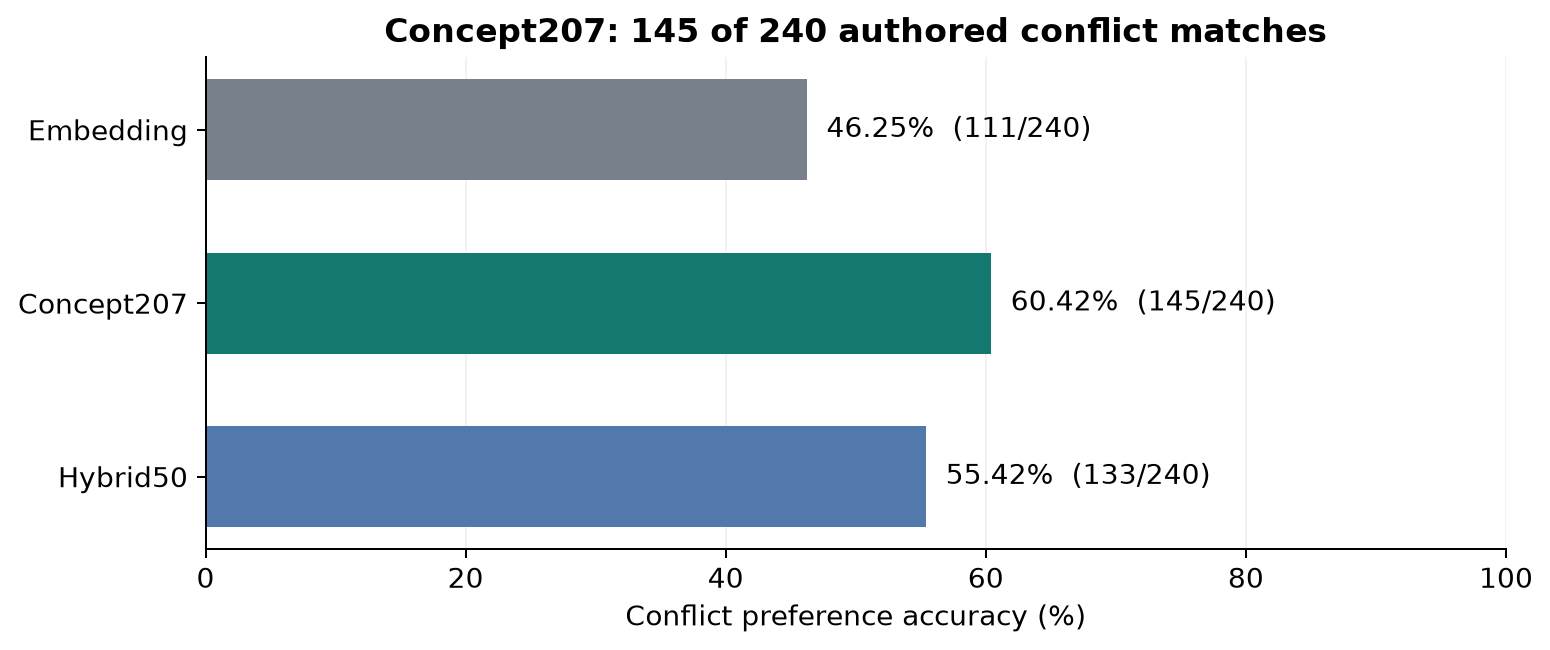

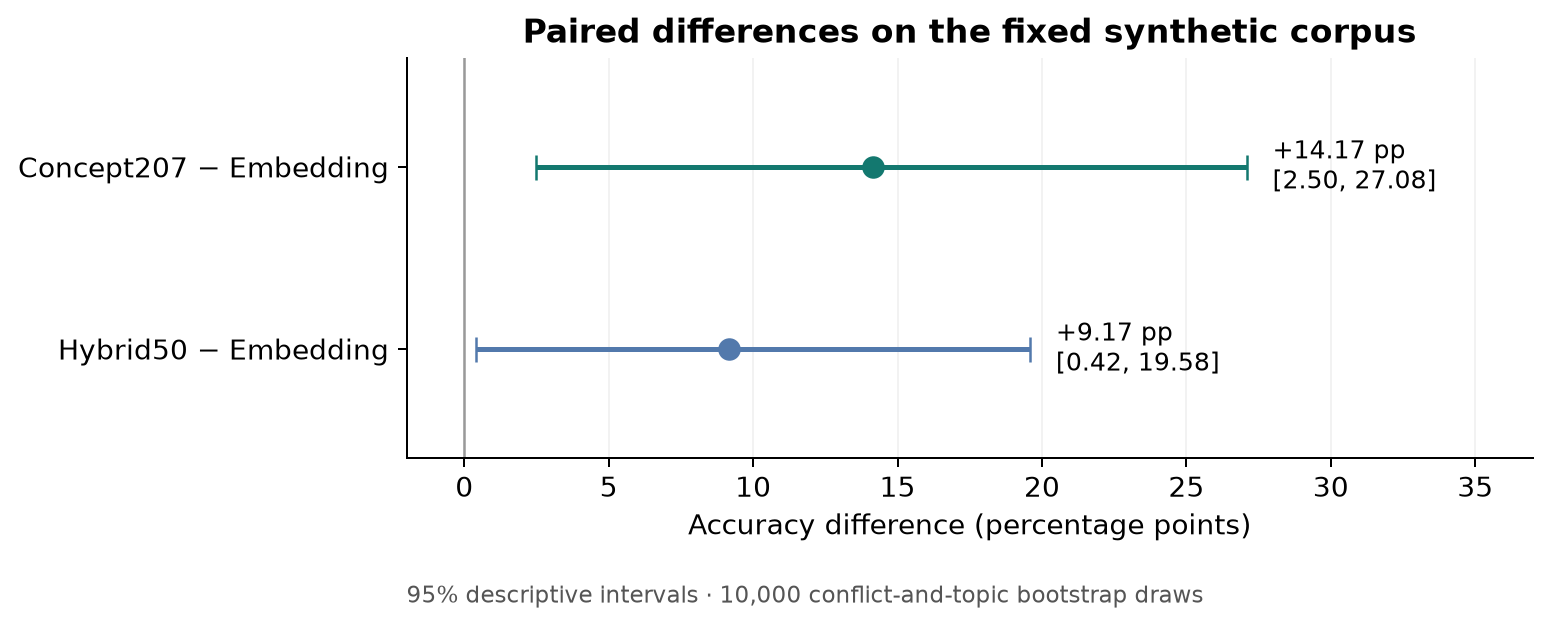

### Exploratory corpus retrieval — authored conflict relevance

Method,Queries,nDCG@5,nDCG@10
Embedding,240,0.6168,0.5576
Concept207,240,0.5995,0.5458
Hybrid50,240,0.6725,0.6099


In [4]:
results_table = summary.set_index("method").loc[METHODS, ["correct_score", "n_triplets", "accuracy", "mean_margin"]].copy()
results_table.insert(0, "Method", [NAMES[m] for m in results_table.index])
results_table["Accuracy (%)"] = 100 * results_table.pop("accuracy")
display(results_table.style.hide(axis="index").format({"correct_score": "{:.0f}", "n_triplets": "{:.0f}", "Accuracy (%)": "{:.2f}", "mean_margin": "{:.5f}"}))
primary_intervals = intervals[(intervals.baseline == "embedding") & (intervals.grouping == "conflict_and_topic") & (intervals.metric == "accuracy")].set_index("method").loc[METHODS[1:], ["difference", "low", "high"]] * 100
primary_intervals.insert(0, "Method", [NAMES[m] for m in primary_intervals.index])
display(primary_intervals.style.hide(axis="index").format({"difference": "{:+.2f}", "low": "{:+.2f}", "high": "{:+.2f}"}))
subprocess.run([sys.executable, "scripts/make_figures.py", "--results", str(RELATIVE_RUN), "--output", str(RELATIVE_RUN / "figures")], cwd=ROOT, check=True)
display(Image(filename=str(RUN / "figures/accuracy.png")))
display(Image(filename=str(RUN / "figures/effects.png")))
display(Markdown("### Exploratory corpus retrieval — authored conflict relevance"))
retrieval_table = pd.read_csv(RUN / "retrieval_summary.csv").set_index("method").loc[METHODS, ["n_queries", "ndcg_at_5", "ndcg_at_10"]].copy()
retrieval_table.insert(0, "Method", [NAMES[m] for m in retrieval_table.index])
retrieval_table = retrieval_table.rename(columns={"n_queries": "Queries", "ndcg_at_5": "nDCG@5", "ndcg_at_10": "nDCG@10"})
display(retrieval_table.style.hide(axis="index").format({"Queries": "{:.0f}", "nDCG@5": "{:.4f}", "nDCG@10": "{:.4f}"}))

## Random controls and robustness

Thirty Gaussian projections and thirty random orientations with the same singular spectrum as the attribute map are evaluated on the same texts, separately and in 50/50 mixtures. Seeds and all individual scores are retained. The control maps are not additional independent text datasets.

Concept207 exceeds all 60 standalone controls in the reference run; the best control reaches 55.83%, compared with 60.42% for Concept207. One of the 60 control mixtures exceeds Hybrid50. Excluding each author in turn leaves a Concept207 gain of +12.22 to +17.22 percentage points; the Hybrid50 range is +7.22 to +11.11 points.

Both final AI audits agree with the authored choice on 225 triplets. This is a sensitivity subset; the primary evaluation includes all 240. Initial and repaired audit responses are preserved. Candidate-letter/explanation alignment corrections increased joint agreement from 140 to 225; this procedure does not constitute independent human validation.


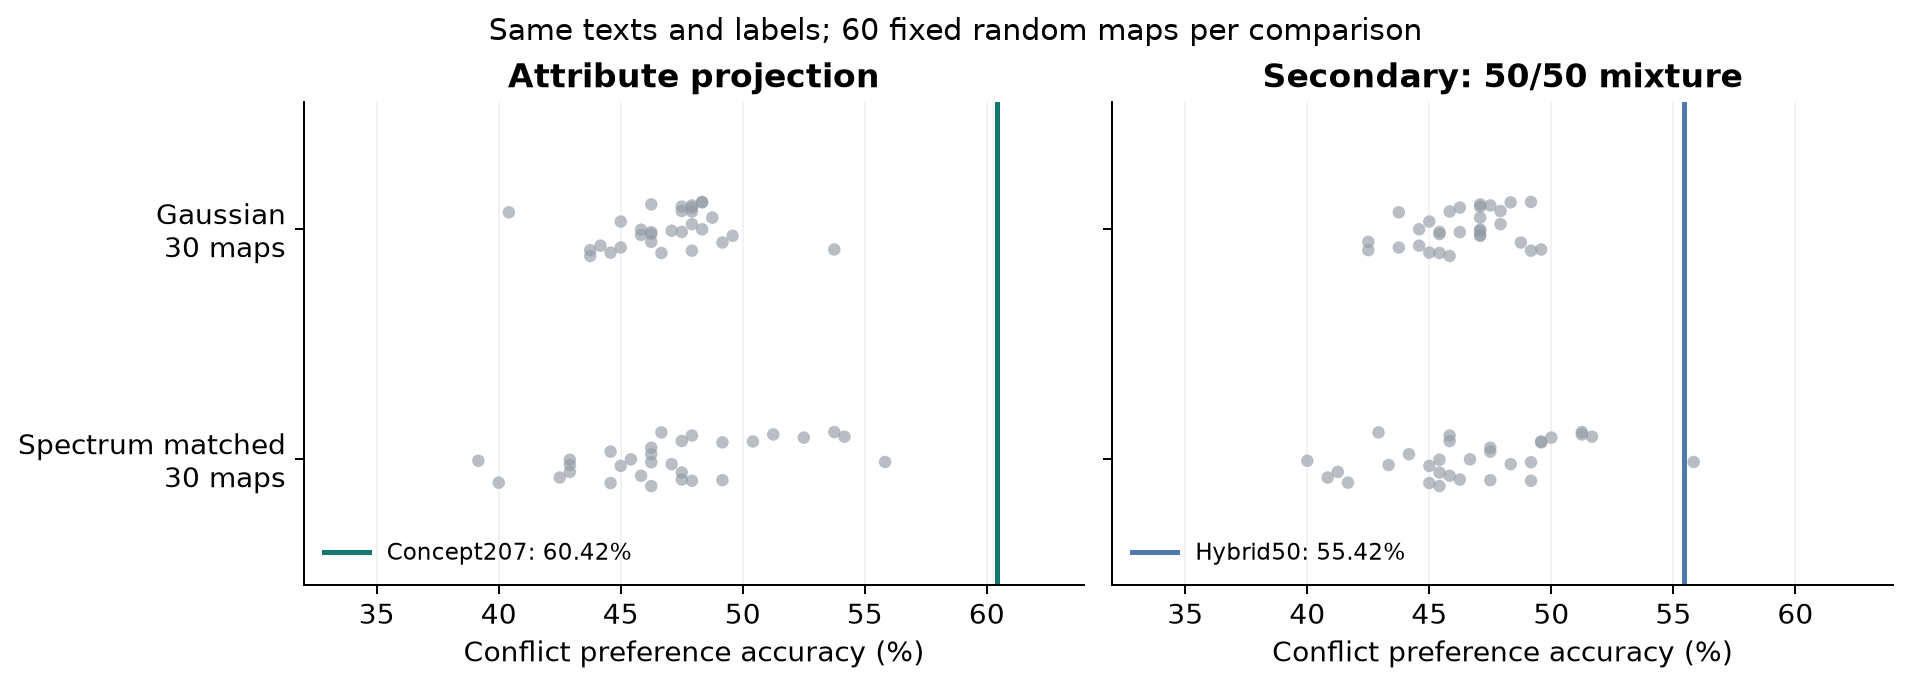

method,baseline,improved_triplets,worsened_triplets,unchanged_triplets
concept207,embedding,55,21,164
hybrid50,embedding,36,14,190


method,n_triplets,correct_score,accuracy,mean_margin,n_conflicts,n_topics,interpretable
concept207,225,133,0.5911,0.05295,12,10,True
embedding,225,104,0.4622,-0.01211,12,10,True
hybrid50,225,123,0.5467,0.02042,12,10,True


The run's verification record is stored alongside its CSV tables in `verification.json`.

In [5]:
display(Image(filename=str(RUN / "figures/random_controls.png")))
transitions = pd.read_csv(RUN / "transitions.csv")
display(transitions[transitions.baseline == "embedding"].set_index("method").loc[METHODS[1:]].reset_index().style.hide(axis="index"))
display(pd.read_csv(RUN / "agreed_audit_sensitivity.csv").style.hide(axis="index").format({"accuracy": "{:.4f}", "mean_margin": "{:.5f}"}))
verification = json.loads((RUN / "verification.json").read_text())
display(Markdown("The run's verification record is stored alongside its CSV tables in `verification.json`."))

## Conclusion and scope

On the fixed 240-triplet corpus, Concept207 increases accuracy from **46.25% to 60.42% (+14.17 percentage points)**, correcting 55 baseline errors and introducing 21 new ones. Its accuracy exceeds each of the 60 standalone random controls. The secondary Hybrid50 representation achieves 55.42% (+9.17 points). These observations establish a measurable improvement for the chosen attribute geometry on this test.

**For exploratory corpus retrieval, Hybrid50 outperforms both component methods separately on this fixed corpus:** nDCG@5 is **0.6725**, compared with 0.6168 for Embedding and 0.5995 for Concept207; nDCG@10 is **0.6099**, compared with 0.5576 and 0.5458, respectively. Concept207 remains the strongest method on the original triplet accuracy task.

Triplet accuracy checks the ordering of B against one same-topic C; nDCG evaluates the top of a ranking over all 719 other texts. The different method rankings therefore concern different tasks. A possible interpretation is that the two component similarities complement each other in corpus retrieval, but these results do not establish that mechanism or a universal advantage for the hybrid.

The corpus and labels are AI-generated, thematic roles require further validation, and no independent human assessment was performed. The primary results concern a two-candidate conflict-matching task. The exploratory nDCG extension uses the same authored conflict labels; these experiments do not establish general retrieval performance or a universal advantage of projection.

**Editorial provenance.** Concept207 is the author's primary research focus in this presentation. The historical assistant-written protocol designated Hybrid50 − embedding as its principal contrast. That protocol, all pre-score inputs and all computed comparisons are retained; the present emphasis is not represented as the original protocol priority.

**Materials:** [README](https://github.com/sarrumkin/concept-projection-dilemmas#readme), [methods](https://github.com/sarrumkin/concept-projection-dilemmas/blob/main/docs/methods.md), [data and audit history](https://github.com/sarrumkin/concept-projection-dilemmas/blob/main/docs/data.md), [research branch reports](https://github.com/sarrumkin/concept-projection-dilemmas/blob/main/docs/research_branches.md).

**Sources:** [Bhatia et al. (2025)](https://doi.org/10.1073/pnas.2406489122), [MiniLM model card](https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2).
